Academic Performance Dataset:
   Roll_No     Name Department  Marks   Age  Attendance
0        1  Krushna         IT   78.0  20.0        85.0
1        2     Amit       COMP   85.0  21.0        90.0
2        3   Shahid         IT   90.0  19.0        88.0
3        4    Rahul        NaN    NaN  20.0        76.0
4        5     Yash       ENTC   65.0   NaN        95.0
5        6   Ayesha       COMP   72.0  22.0         NaN
6        7  Prerana         IT  150.0  21.0        70.0
7        8    Amita       COMP   80.0  20.0        82.0
8        9    Sneha       ENTC   66.0  19.0        91.0
9       10   Tanaya         IT   95.0  23.0        89.0

Shape of Dataset:
(10, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Roll_No     10 non-null     int64  
 1   Name        10 non-null     object 
 2   Department  9 non-null      object 

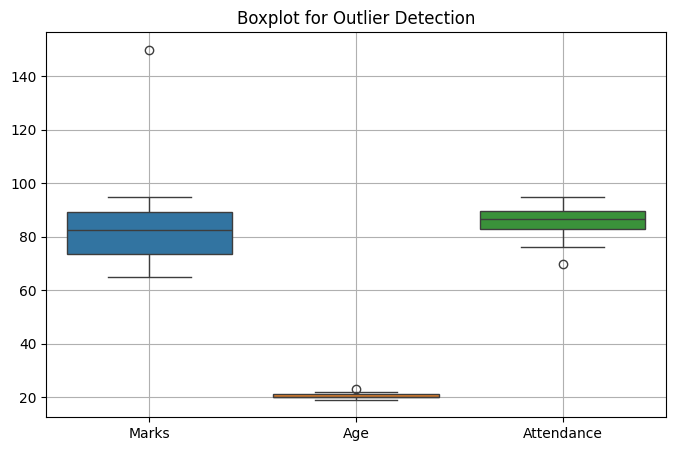


Lower Limit: 49.958333333333336
Upper Limit: 112.73611111111111

Outliers in Marks Column:
   Roll_No     Name Department  Marks   Age  Attendance
6        7  Prerana         IT  150.0  21.0        70.0

Dataset After Outlier Treatment:
   Roll_No     Name Department      Marks   Age  Attendance
0        1  Krushna         IT  78.000000  20.0   85.000000
1        2     Amit       COMP  85.000000  21.0   90.000000
2        3   Shahid         IT  90.000000  19.0   88.000000
3        4    Rahul         IT  86.777778  20.0   76.000000
4        5     Yash       ENTC  65.000000  20.0   95.000000
5        6   Ayesha       COMP  72.000000  22.0   85.111111
6        7  Prerana         IT  82.500000  21.0   70.000000
7        8    Amita       COMP  80.000000  20.0   82.000000
8        9    Sneha       ENTC  66.000000  19.0   91.000000
9       10   Tanaya         IT  95.000000  23.0   89.000000


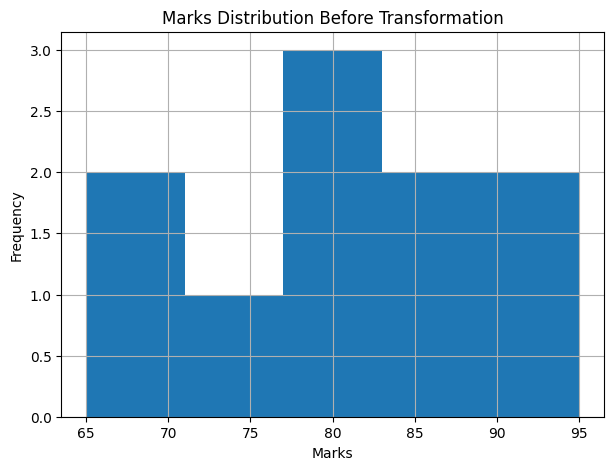


Log Transformed Marks:
       Marks  Log_Marks
0  78.000000   4.356709
1  85.000000   4.442651
2  90.000000   4.499810
3  86.777778   4.463351
4  65.000000   4.174387
5  72.000000   4.276666
6  82.500000   4.412798
7  80.000000   4.382027
8  66.000000   4.189655
9  95.000000   4.553877


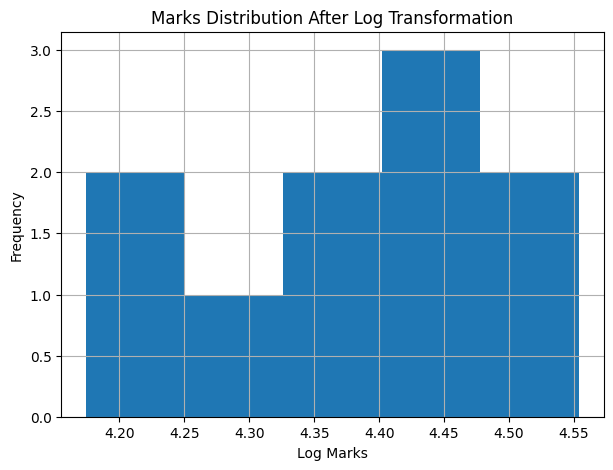


Normalized Dataset:
      Marks  Attendance
0  0.433333    0.600000
1  0.666667    0.800000
2  0.833333    0.720000
3  0.725926    0.240000
4  0.000000    1.000000
5  0.233333    0.604444
6  0.583333    0.000000
7  0.500000    0.480000
8  0.033333    0.840000
9  1.000000    0.760000

Standardized Age:
   Standardized_Age
0         -0.415227
1          0.415227
2         -1.245682
3         -0.415227
4         -0.415227
5          1.245682
6          0.415227
7         -0.415227
8         -1.245682
9          2.076137

Final Processed Dataset:
   Roll_No     Name Department     Marks   Age  Attendance  Log_Marks
0        1  Krushna         IT  0.433333  20.0    0.600000   4.356709
1        2     Amit       COMP  0.666667  21.0    0.800000   4.442651
2        3   Shahid         IT  0.833333  19.0    0.720000   4.499810
3        4    Rahul         IT  0.725926  20.0    0.240000   4.463351
4        5     Yash       ENTC  0.000000  20.0    1.000000   4.174387
5        6   Ayesha       COMP

In [1]:
# 2) Detect Outliers using IQR Method

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


# Create Academic Performance dataset

data = {
    'Roll_No': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    
    'Name': [
        'Krushna', 'Amit', 'Shahid', 'Rahul', 'Yash',
        'Ayesha', 'Prerana', 'Amita', 'Sneha', 'Tanaya'
    ],
    
    'Department': [
        'IT', 'COMP', 'IT', np.nan, 'ENTC',
        'COMP', 'IT', 'COMP', 'ENTC', 'IT'
    ],
    
    'Marks': [
        78, 85, 90, np.nan, 65,
        72, 150, 80, 66, 95
    ],
    
    'Age': [
        20, 21, 19, 20, np.nan,
        22, 21, 20, 19, 23
    ],
    
    'Attendance': [
        85, 90, 88, 76, 95,
        np.nan, 70, 82, 91, 89
    ]
}


# Convert dictionary into DataFrame

df = pd.DataFrame(data)


# Display dataset

print("Academic Performance Dataset:")
print(df)


# Display shape of dataset

print("\nShape of Dataset:")
print(df.shape)


# Display dataset information

print("\nDataset Information:")
print(df.info())


# Check missing values

print("\nMissing Values:")
print(df.isnull().sum())


# Display statistical summary

print("\nStatistical Summary:")
print(df.describe())


# Fill missing values in Department column using mode

df['Department'] = df['Department'].fillna(df['Department'].mode()[0])


# Fill missing values in Marks column using mean

df['Marks'] = df['Marks'].fillna(df['Marks'].mean())


# Fill missing values in Age column using median

df['Age'] = df['Age'].fillna(df['Age'].median())


# Fill missing values in Attendance column using mean

df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean())


# Display dataset after handling missing values

print("\nDataset After Handling Missing Values:")
print(df)


# Check missing values again

print("\nMissing Values After Treatment:")
print(df.isnull().sum())


# Boxplot for outlier detection

plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['Marks', 'Age', 'Attendance']])

plt.title("Boxplot for Outlier Detection")
plt.grid(True)

plt.show()


# Detect outliers using IQR method for Marks column

Q1 = df['Marks'].quantile(0.25)
Q3 = df['Marks'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


# Display limits

print("\nLower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


# Detect outliers

outliers = df[(df['Marks'] < lower_limit) | (df['Marks'] > upper_limit)]

print("\nOutliers in Marks Column:")
print(outliers)


# Replace outliers using median

median_marks = df['Marks'].median()

df['Marks'] = np.where(
    df['Marks'] > upper_limit,
    median_marks,
    df['Marks']
)


# Display dataset after outlier treatment

print("\nDataset After Outlier Treatment:")
print(df)


# Plot histogram before transformation

plt.figure(figsize=(7, 5))

plt.hist(df['Marks'], bins=5)

plt.title("Marks Distribution Before Transformation")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()


# Apply logarithmic transformation

df['Log_Marks'] = np.log(df['Marks'])


# Display transformed values

print("\nLog Transformed Marks:")
print(df[['Marks', 'Log_Marks']])


# Plot histogram after transformation

plt.figure(figsize=(7, 5))

plt.hist(df['Log_Marks'], bins=5)

plt.title("Marks Distribution After Log Transformation")
plt.xlabel("Log Marks")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()


# Apply Min-Max Normalization

scaler = MinMaxScaler()

df[['Marks', 'Attendance']] = scaler.fit_transform(
    df[['Marks', 'Attendance']]
)


# Display normalized values

print("\nNormalized Dataset:")
print(df[['Marks', 'Attendance']])


# Apply Standardization

standard_scaler = StandardScaler()

scaled_data = standard_scaler.fit_transform(
    df[['Age']]
)


# Convert standardized data into DataFrame

scaled_df = pd.DataFrame(scaled_data, columns=['Standardized_Age'])


# Display standardized values

print("\nStandardized Age:")
print(scaled_df)


# Final dataset

print("\nFinal Processed Dataset:")
print(df)